In [3]:
from qutip import *
import numpy as np
import matplotlib.pyplot as plt
from jcm_lib import fases,concurrence_ali
import matplotlib as mpl
from entrelazamiento_lib import negativity_hor
import os 

#ES EL HERMANO DE LEEDOR_JCM.PY, LA IDEA ES HACER SIMULACIONES LARGAS ACA Y DESPUES LEERLAS CON LEEDOR.
# LAS SIMULACIONES QUE HACEMOS ACA SON DE JCM DE 1 ATOMO Y HAY VARIAS COSAS
# 1. SUPERFICIE DE FG. BARREMOS EN DELTA Y HACEMOS UN PLOT DE LA FG
# 2. TRAYECTORIAS DE BLOCH
# 3. GRAFICOS TRANQUI PARA MIRAR CASOS PARTICULARES DE FG
# 4. BLOCH DISIP VS UNIT
# 5. BLOCH BARRIDA EN CONDICION INICIAL Y ENTRELAZAMIENTO DE CADA EVOLUCION DE LA CONDICION INICIAL CON HEATMAP

# script_path = os.path.dirname(__file__)  #DEFINIMOS EL PATH AL FILE GENERICAMENTE PARA QUE FUNCIONE DESDE CUALQUIER COMPU
# os.chdir(script_path)

e=basis(2,0)
gr=basis(2,1)

N_c=4

e0=tensor(e,basis(N_c,0)) #1
e1=tensor(e,basis(N_c,1)) #2
g0=tensor(gr,basis(N_c,0)) #3
g1=tensor(gr,basis(N_c,1)) #4
g2=tensor(gr,basis(N_c,2)) 

sz=tensor(sigmaz(),qeye(N_c))
sx=tensor(sigmax(),qeye(N_c))
sy=tensor(sigmay(),qeye(N_c))
sp=tensor(sigmap(),qeye(N_c))
sm=tensor(sigmam(),qeye(N_c))
a=tensor(qeye(2),destroy(N_c))

w_0=1
g=0.01*w_0

def omega_n(n_:int,delta:float):
    return np.sqrt(delta**2+4*g**2*n_)

def cos_theta_n(n_:int,delta:float):
    return np.sqrt((omega_n(n_,delta)+delta)/(2*omega_n(n_,delta)))

def sin_theta_n(n_:int,delta:float):
    return np.sqrt((omega_n(n_,delta)-delta)/(2*omega_n(n_,delta)))

def pr(estado):
    return estado.unit()*estado.unit().dag()

def omega_n(n_:int,delta:float,chi:float):
    return np.sqrt((delta-chi*(2*n_-1))**2+4*g**2*n_)

def vectorBloch(v1,v2,sol_states,steps,ciclos_bloch,T,t_final,points):
    sz_1=pr(v1)-pr(v2)
    sx_1=v1*v2.dag()+v2*v1.dag()
    sy_1=-1j*v1*v2.dag()+1j*v2*v1.dag()

    expect_sx_1=[expect(sx_1,sol_states[i]) for i in range(0,int(steps*ciclos_bloch*T/t_final),int(steps*ciclos_bloch*T/t_final/points))]
    expect_sy_1=[expect(sy_1,sol_states[i]) for i in range(0,int(steps*ciclos_bloch*T/t_final),int(steps*ciclos_bloch*T/t_final/points))]
    expect_sz_1=[expect(sz_1,sol_states[i]) for i in range(0,int(steps*ciclos_bloch*T/t_final),int(steps*ciclos_bloch*T/t_final/points))]
    return [expect_sx_1,expect_sy_1,expect_sz_1]


Primero vemos como es la $\delta\phi$ para diferentes valores de $\Delta$ eligiendo una condicion inicial perpendicular a la direccion del Hamiltoniano. Aca lo que tambien hay que tener en cuenta es que las simulaiciones estan hechas cada una con su frecuencia que depende de $\Delta$, hasta un tiempo final $t_f=6T=6 \frac{2\pi}{\Omega(\Delta)}$ y por lo tanto cada simulacion hace 6 oscilaciones: esto significa que el tiempo final de cada simulacion es diferente para cada valor de $\Delta$. 

1.3296008738450382e-10
1.3317058566997275e-10


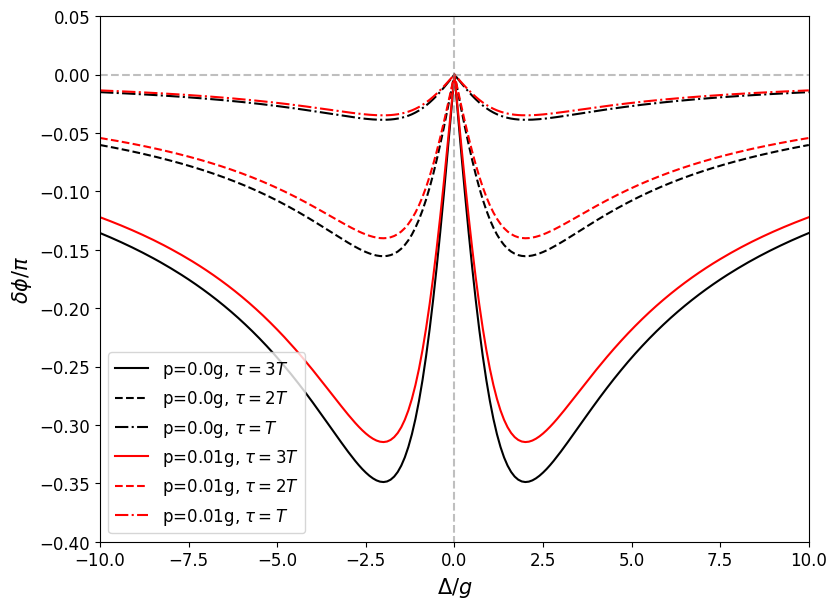

In [12]:
w_0=1
g=0.01*w_0

def T(delta,x):
    return 2*np.pi/np.sqrt(4*g**2+(delta-x)**2)

p=[0,0.01*g]

delta_array=np.linspace(-10*g,10*g,201)

perp3=np.zeros((len(p),len(delta_array)))
perp2=np.zeros((len(p),len(delta_array)))
perp1=np.zeros((len(p),len(delta_array)))



perp3[0]=np.loadtxt('robusteces/jcm/perpendicular 3t p=0.0g x=0.0g (2).txt')%2-2
perp3[1]=np.loadtxt('robusteces/jcm/perpendicular 3t p=0.01g x=0.0g (2).txt')%2-2
# perp3[0][100]+=2
perp3[1][100]+=2

perp2[0]=np.loadtxt('robusteces/jcm/perpendicular 2t p=0.0g x=0.0g (2).txt')%2-2
perp2[1]=np.loadtxt('robusteces/jcm/perpendicular 2t p=0.01g x=0.0g (2).txt')%2-2
perp2[0][100]+=2
perp2[1][100]+=2

perp1[0]=np.loadtxt('robusteces/jcm/perpendicular 1t p=0.0g x=0.0g (2).txt')%2-2
perp1[1]=np.loadtxt('robusteces/jcm/perpendicular 1t p=0.01g x=0.0g (2).txt')%2-2
perp1[0][100]+=2
perp1[1][100]+=2

print(perp2[0][100])
print(perp2[1][100])
colors_p=['black','red']

fig_perp=plt.figure(figsize=(8,6),dpi=100)
ax_perp=fig_perp.add_subplot()
ax_perp.set_xlabel(r'$\Delta/g$')
ax_perp.set_ylabel(r'$\delta\phi/\pi$')
for j_p in range(len(p)):
    ax_perp.plot(delta_array/g,perp3[j_p],color=colors_p[j_p],label=f'p={p[j_p]/g}g, $\\tau=3T$')
    ax_perp.plot(delta_array/g,perp2[j_p],color=colors_p[j_p],linestyle='dashed',label=f'p={p[j_p]/g}g, $\\tau=2T$')
    ax_perp.plot(delta_array/g,perp1[j_p],color=colors_p[j_p],linestyle='dashdot',label=f'p={p[j_p]/g}g, $\\tau=T$')

ax_perp.hlines(0,-10,10,colors='grey',linestyles='dashed',alpha=0.5)
ax_perp.vlines(0,-1,0.05,colors='grey',linestyles='dashed',alpha=0.5)
ax_perp.set_xlim(-10,10)
ax_perp.set_ylim(-0.4,0.05)
ax_perp.legend()
plt.show()

1.0690723259987323e-06
1.0690636409460552e-06


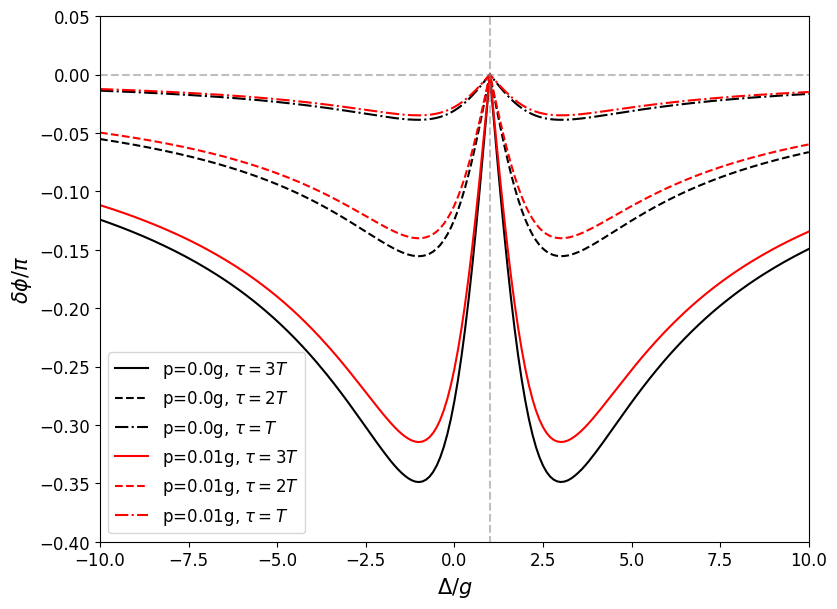

In [13]:
w_0=1
g=0.01*w_0

def T(delta,x):
    return 2*np.pi/np.sqrt(4*g**2+(delta-x)**2)

p=[0,0.01*g]

delta_array=np.linspace(-10*g,10*g,201)

perp3=np.zeros((len(p),len(delta_array)))
perp2=np.zeros((len(p),len(delta_array)))
perp1=np.zeros((len(p),len(delta_array)))



perp3[0]=np.loadtxt('robusteces/jcm/perpendicular 3t p=0.0g x=1.0g (2).txt')%2-2
perp3[1]=np.loadtxt('robusteces/jcm/perpendicular 3t p=0.01g x=1.0g (2).txt')%2-2
perp3[0][110]+=2
perp3[1][110]+=2

perp2[0]=np.loadtxt('robusteces/jcm/perpendicular 2t p=0.0g x=1.0g (2).txt')%2-2
perp2[1]=np.loadtxt('robusteces/jcm/perpendicular 2t p=0.01g x=1.0g (2).txt')%2-2
perp2[0][110]+=2
perp2[1][110]+=2

perp1[0]=np.loadtxt('robusteces/jcm/perpendicular 1t p=0.0g x=1.0g (2).txt')%2-2
perp1[1]=np.loadtxt('robusteces/jcm/perpendicular 1t p=0.01g x=1.0g (2).txt')%2-2
perp1[0][110]+=2
perp1[1][110]+=2

print(perp1[0][110])
print(perp1[1][110])
colors_p=['black','red']

fig_perp=plt.figure(figsize=(8,6),dpi=100)
ax_perp=fig_perp.add_subplot()
ax_perp.set_xlabel(r'$\Delta/g$')
ax_perp.set_ylabel(r'$\delta\phi/\pi$')
for j_p in range(len(p)):
    ax_perp.plot(delta_array/g,perp3[j_p],color=colors_p[j_p],label=f'p={p[j_p]/g}g, $\\tau=3T$')
    ax_perp.plot(delta_array/g,perp2[j_p],color=colors_p[j_p],linestyle='dashed',label=f'p={p[j_p]/g}g, $\\tau=2T$')
    ax_perp.plot(delta_array/g,perp1[j_p],color=colors_p[j_p],linestyle='dashdot',label=f'p={p[j_p]/g}g, $\\tau=T$')

ax_perp.hlines(0,-10,10,colors='grey',linestyles='dashed',alpha=0.5)
ax_perp.vlines(1,-1,0.05,colors='grey',linestyles='dashed',alpha=0.5)
ax_perp.set_xlim(-10,10)
ax_perp.set_ylim(-0.4,0.05)
ax_perp.legend()
plt.show()



Aca va con el $T_0$, es decir, las simulaciones van todas hasta el mismo tiempo $t_f=6T_0$ y dependiendo de su frecuencia tendran mas o menos oscilaciones

1.3455236924642122e-10
1.3455236924642122e-10


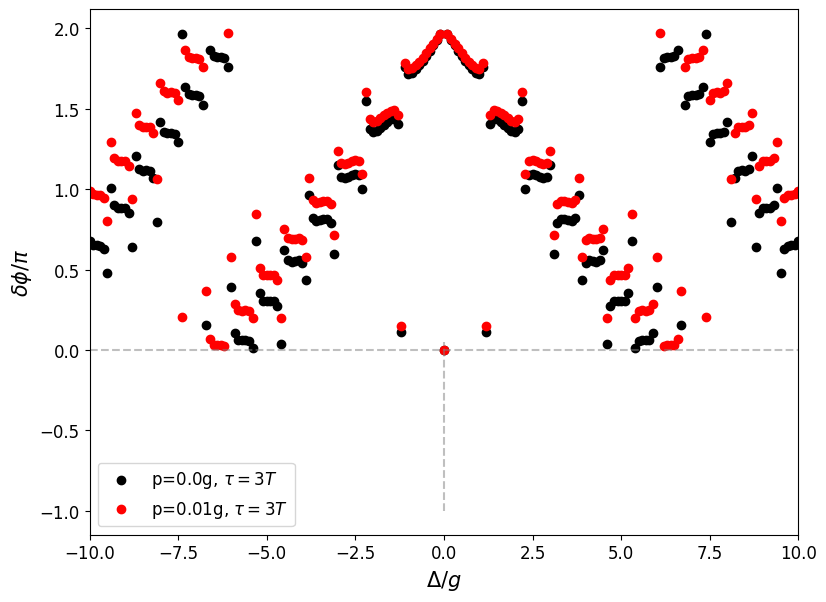

In [15]:
w_0=1
g=0.01*w_0

def T(delta,x):
    return 2*np.pi/np.sqrt(4*g**2+(delta-x)**2)

p=[0,0.01*g]

delta_array=np.linspace(-10*g,10*g,201)

perp3=np.zeros((len(p),len(delta_array)))
perp2=np.zeros((len(p),len(delta_array)))
perp1=np.zeros((len(p),len(delta_array)))



perp3[0]=np.loadtxt('robusteces/jcm/perpendicular 3t0 p=0.0g x=0.0g.txt')%2
perp3[1]=np.loadtxt('robusteces/jcm/perpendicular 3t0 p=0.01g x=0.0g.txt')%2
# perp3[0][100]+=2
# perp3[1][100]+=2

perp2[0]=np.loadtxt('robusteces/jcm/perpendicular 2t0 p=0.0g x=0.0g.txt')
perp2[1]=np.loadtxt('robusteces/jcm/perpendicular 2t0 p=0.01g x=0.0g.txt')
# perp2[0][100]+=2
# perp2[1][100]+=2

perp1[0]=np.loadtxt('robusteces/jcm/perpendicular 1t0 p=0.0g x=0.0g.txt')
perp1[1]=np.loadtxt('robusteces/jcm/perpendicular 1t0 p=0.01g x=0.0g.txt')
# perp1[0][100]+=2
# perp1[1][100]+=2

print(perp3[0][100])
print(perp3[1][100])
colors_p=['black','red']

fig_perp=plt.figure(figsize=(8,6),dpi=100)
ax_perp=fig_perp.add_subplot()
ax_perp.set_xlabel(r'$\Delta/g$')
ax_perp.set_ylabel(r'$\delta\phi/\pi$')
for j_p in range(len(p)):
    ax_perp.scatter(delta_array/g,perp3[j_p],color=colors_p[j_p],label=f'p={p[j_p]/g}g, $\\tau=3T$')
    # ax_perp.plot(delta_array/g,perp2[j_p],color=colors_p[j_p],linestyle='dashed',label=f'p={p[j_p]/g}g, $\\tau=2T$')
    # ax_perp.plot(delta_array/g,perp1[j_p],color=colors_p[j_p],linestyle='dashdot',label=f'p={p[j_p]/g}g, $\\tau=T$')

ax_perp.hlines(0,-10,10,colors='grey',linestyles='dashed',alpha=0.5)
ax_perp.vlines(0,-1,0.05,colors='grey',linestyles='dashed',alpha=0.5)
ax_perp.set_xlim(-10,10)
# ax_perp.set_ylim(-0.4,0.05)
ax_perp.legend()
plt.show()

Ahora vemos como depende, fijado $\Delta=\chi$ la condicion de resonancia, la $\delta\phi$ en funcion de la condicion inicial, que esta parametrizada por el angulo $\theta_0$.

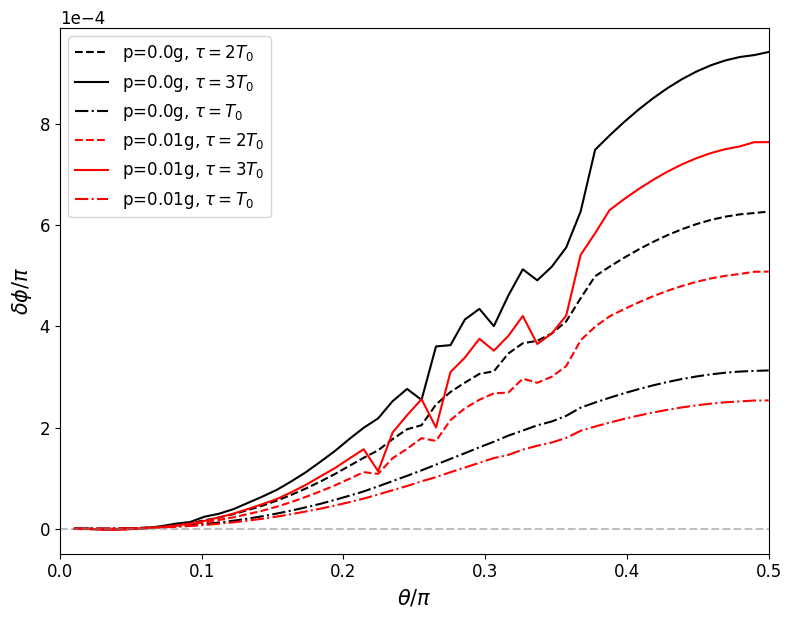

In [25]:
num_tita=50

tita_array=np.linspace(0,np.pi/2,num_tita)

tita3=np.zeros((len(p),len(tita_array)))
tita2=np.zeros((len(p),len(tita_array)))
tita1=np.zeros((len(p),len(tita_array)))

tita3[0]=np.loadtxt('robusteces/jcm/tita 3t p=0.0g.txt')
tita3[1]=np.loadtxt('robusteces/jcm/tita 3t p=0.01g.txt')

tita2[0]=np.loadtxt('robusteces/jcm/tita 2t p=0.0g.txt')
tita2[1]=np.loadtxt('robusteces/jcm/tita 2t p=0.01g.txt')

tita1[0]=np.loadtxt('robusteces/jcm/tita 1t p=0.0g.txt')
tita1[1]=np.loadtxt('robusteces/jcm/tita 1t p=0.01g.txt')

colors_p=['black','red']

fig_tita=plt.figure(figsize=(8,6),dpi=100)
ax_tita=fig_tita.add_subplot()
ax_tita.set_xlabel(r'$\theta/\pi$')
ax_tita.set_ylabel(r'$\delta\phi/\pi$')

for j_p in range(len(p)):
    ax_tita.plot(tita_array[1:]/np.pi,tita2[j_p][1:],color=colors_p[j_p],linestyle='dashed',label=f'p={p[j_p]/g}g, $\\tau=2T_0$')
    ax_tita.plot(tita_array[1:]/np.pi,tita3[j_p][1:],color=colors_p[j_p],label=f'p={p[j_p]/g}g, $\\tau=3T_0$')
    ax_tita.plot(tita_array[1:]/np.pi,tita1[j_p][1:],color=colors_p[j_p],linestyle='dashdot',label=f'p={p[j_p]/g}g, $\\tau=T_0$')

ax_tita.hlines(0,0,0.5,colors='grey',linestyles='dashed',alpha=0.5)
ax_tita.set_xlim(0,0.5)
# ax_tita.set_ylim(-0.5,0)
ax_tita.ticklabel_format(axis='y',style='sci',scilimits=(0,0))
ax_tita.legend()
plt.show()

Ahora vienen las Negatividades

In [23]:
def heatplot(t,y,z_data:list,title:str,ylabel):
    fig_u=plt.figure(figsize=(8,6),dpi=100)
    ax_u=fig_u.add_subplot()
    ax_u.set_title(title,pad=2,fontsize=20)
    ax_u.set_xlabel('$t/T_0$')
    ax_u.set_ylabel(ylabel)
    c0 = ax_u.pcolor(t, y, z_data, shading='auto', cmap='Reds',vmin=0,vmax=0.5)
    # contour_u = ax_u.contourf(t/T, y, z_data,levels=[0,0.01],colors='black',linewidths=1)
    # ax_u.clabel(contour_u, fmt="%.1f",colors='red',fontsize=10)
    fig_u.colorbar(c0, ax=ax_u,shrink=0.7)
    # fig_u.savefig(rf'graficos\negativity\{psi0Name} {title} x={x/g}g k={k/g}g J={J/g}g neg delta dis.png')


Primero para la condicion de resonancia, cambiando la condicion inicial parametrizada por $\theta_0$

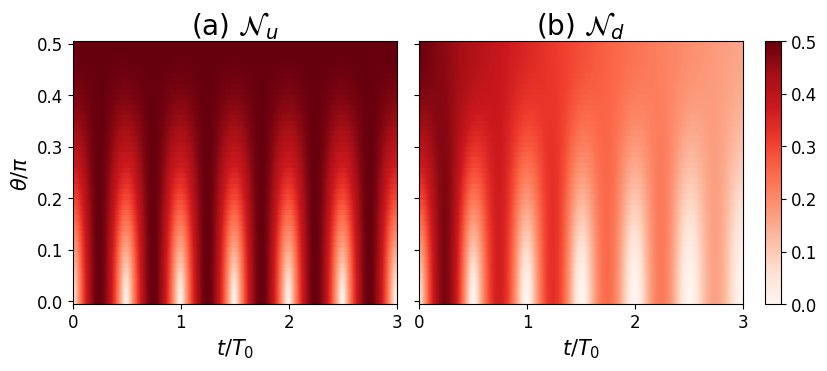

In [15]:
N_u_tita=np.loadtxt(f'robusteces/jcm/negatividad tita u')
# N_p0_tita=np.loadtxt(f'robusteces/jcm/negatividad tita p0')
N_p1_tita=np.loadtxt(f'robusteces/jcm/negatividad tita p1')
w_0=1
g=0.01*w_0

x=0*g
delta=0*g

omega=np.sqrt(4*g**2+(delta-x)**2)

num_ciclos=3
T=2*np.pi/omega
t_final=num_ciclos*T

num_tita=50
tita_array=np.linspace(0,np.pi/2,num_tita)
steps=3000*num_ciclos
t=np.linspace(0,t_final,steps)

import matplotlib.gridspec as gridspec

fig_u = plt.figure(figsize=(8,3), dpi=100)

# Create a GridSpec with 1 row and 3 columns
# Make the third column (colorbar) much smaller
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.1)
# First subplot
ax_u = fig_u.add_subplot(gs[0, 0])
ax_u.set_title(r'(a) $\mathcal{N}_u$', pad=2, fontsize=20)
ax_u.set_xlabel('$t/T_0$')
ax_u.set_ylabel(r"$\theta/\pi$")
c0 = ax_u.pcolor(t/T, tita_array/np.pi, N_u_tita,
                 shading='auto', cmap='Reds', vmin=0, vmax=0.5)

# Second subplot
ax_d = fig_u.add_subplot(gs[0, 1])
ax_d.set_title(r'(b) $\mathcal{N}_d$', pad=2, fontsize=20)
ax_d.set_xlabel('$t/T_0$')
ax_d.set_yticklabels([])
c1 = ax_d.pcolor(t/T, tita_array/np.pi, N_p1_tita,
                 shading='auto', cmap='Reds', vmin=0, vmax=0.5)

# Colorbar axis (small, independent)
ax_colorbar = fig_u.add_subplot(gs[0, 2])
fig_u.colorbar(c1, cax=ax_colorbar)

plt.show()

# heatplot(t/T,tita_array/np.pi,N_u_tita,r'$\mathcal{N}_u$',r"$\theta/\pi$")  
# heatplot(t/T,tita_array/np.pi,N_p0_tita,r'$\mathcal{N}_d$ ; $p=0$',r"$\theta/\pi$")  
# heatplot(t/T,tita_array/np.pi,N_p1_tita,r'$\mathcal{N}_d$ ; $p=0.01g$',r"$\theta/\pi$")  


In [17]:
def heatplot(t,y,z_data:list,title:str,ylabel):
    fig_u=plt.figure(figsize=(8,6),dpi=100)
    ax_u=fig_u.add_subplot()
    ax_u.set_title(title,pad=2,fontsize=20)
    ax_u.set_xlabel('$t/T$')
    ax_u.set_ylabel(ylabel)
    c0 = ax_u.pcolor(t, y, z_data, shading='auto', cmap='Reds',vmin=0,vmax=0.5)
    # contour_u = ax_u.contourf(t/T, y, z_data,levels=[0,0.01],colors='black',linewidths=1)
    # ax_u.clabel(contour_u, fmt="%.1f",colors='red',fontsize=10)
    fig_u.colorbar(c0, ax=ax_u,shrink=0.7)
    # fig_u.savefig(rf'graficos\negativity\{psi0Name} {title} x={x/g}g k={k/g}g J={J/g}g neg delta dis.png')


Ahora barriendo $\Delta$ con condiciones iniciales perpendiculares, y aca nuevamente esta cada simulacion normalizada por su propio tiempo caracteristico $T$, y por lo tanto siempre habra 6 oscilaciones

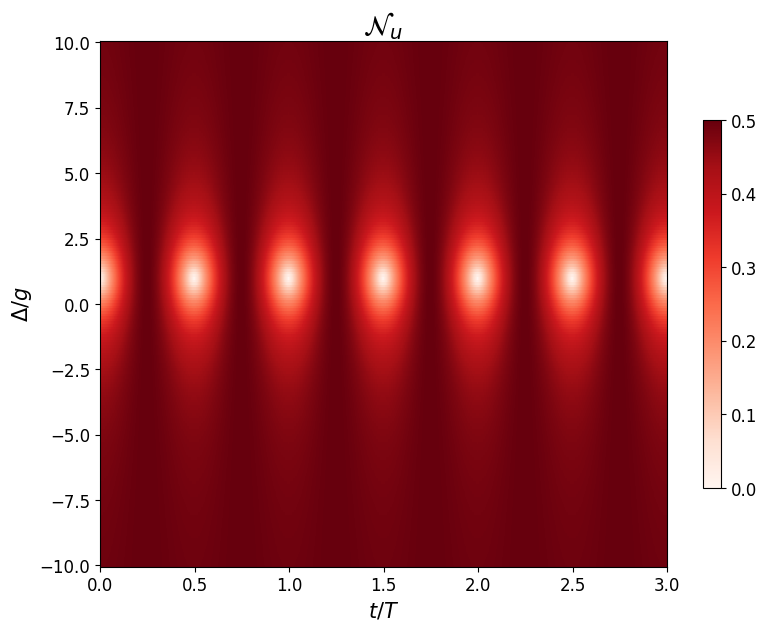

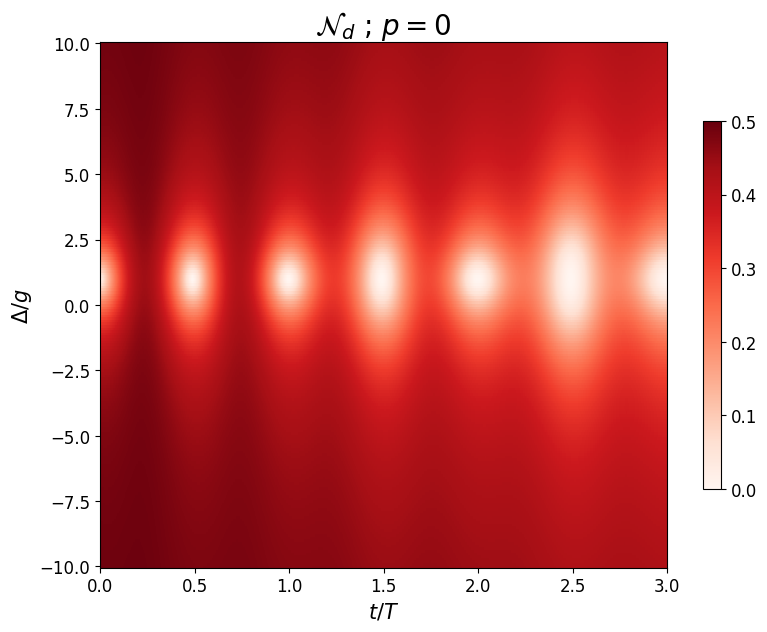

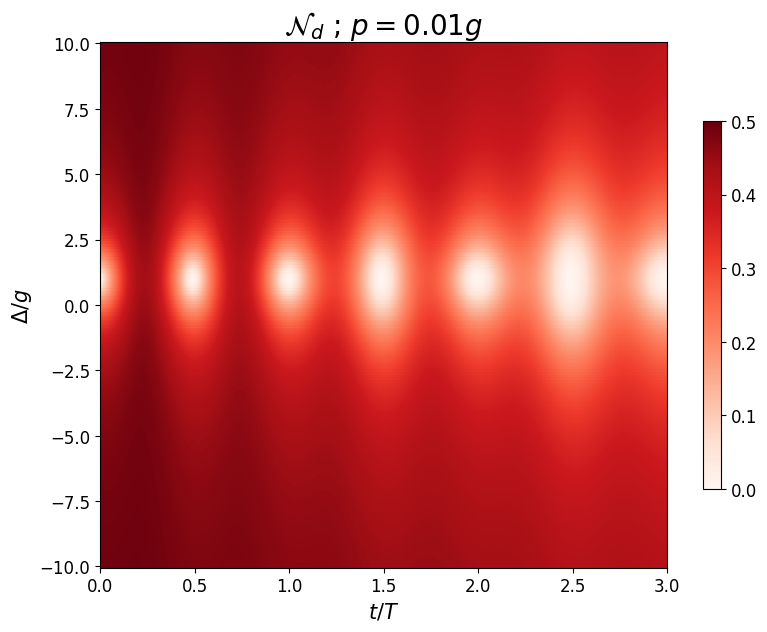

In [18]:
N_u_perp=np.loadtxt(f'robusteces/jcm/negatividad perp u x=1.0g.txt')
N_p0_perp=np.loadtxt(f'robusteces/jcm/negatividad perp p=0 x=1.0g.txt')
N_p1_perp=np.loadtxt(f'robusteces/jcm/negatividad perp p=0_01g x=1.0g.txt')
steps=3000*12
delta_array=np.linspace(-10*g,10*g,201)
omega=2*g
T=2*np.pi/omega
t=np.linspace(0,3,steps)
heatplot(t,delta_array/g,N_u_perp,r'$\mathcal{N}_u$',r'$\Delta/g$')
heatplot(t,delta_array/g,N_p0_perp,r'$\mathcal{N}_d$ ; $p=0$',r'$\Delta/g$')
heatplot(t,delta_array/g,N_p1_perp,r'$\mathcal{N}_d$ ; $p=0.01g$',r'$\Delta/g$')

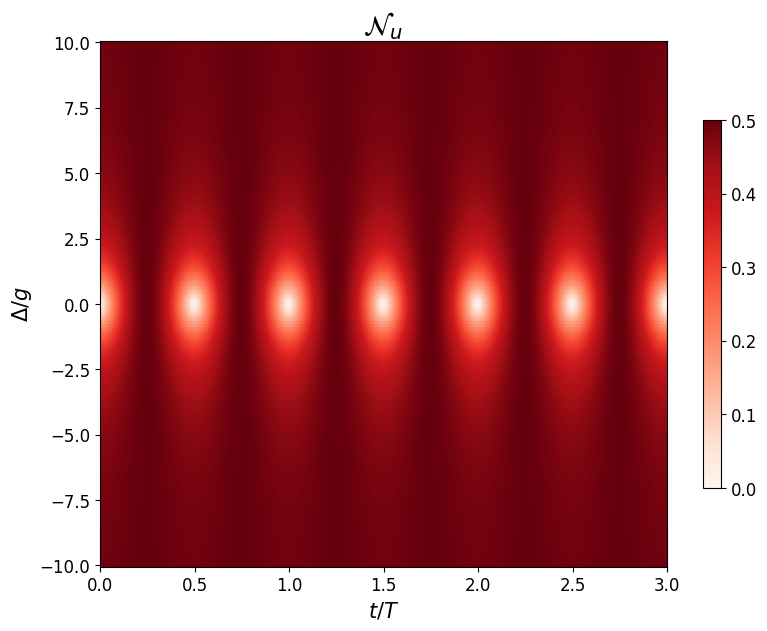

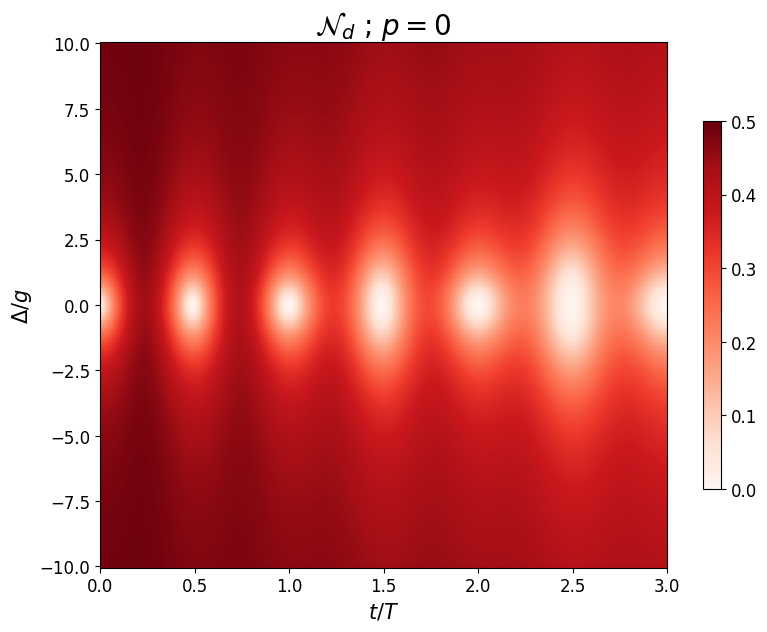

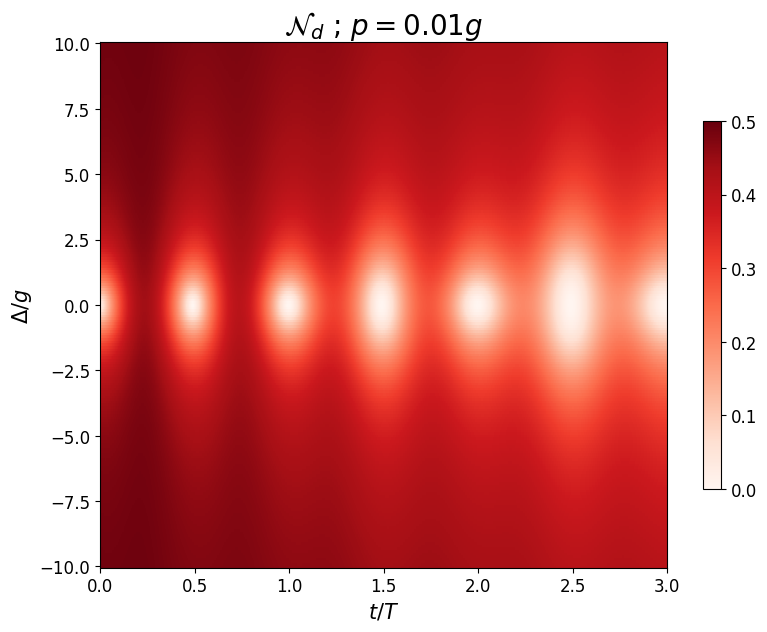

In [19]:
N_u_perp=np.loadtxt(f'robusteces/jcm/negatividad perp u x=0.0g.txt')
N_p0_perp=np.loadtxt(f'robusteces/jcm/negatividad perp p=0 x=0.0g.txt')
N_p1_perp=np.loadtxt(f'robusteces/jcm/negatividad perp p=0_01g x=0.0g.txt')
steps=3000*12
delta_array=np.linspace(-10*g,10*g,201)
omega=2*g
T=2*np.pi/omega
t=np.linspace(0,3,steps)
heatplot(t,delta_array/g,N_u_perp,r'$\mathcal{N}_u$',r'$\Delta/g$')
heatplot(t,delta_array/g,N_p0_perp,r'$\mathcal{N}_d$ ; $p=0$',r'$\Delta/g$')
heatplot(t,delta_array/g,N_p1_perp,r'$\mathcal{N}_d$ ; $p=0.01g$',r'$\Delta/g$')

Ahora vamos con la normalizada segun $T_0$ igual para todos los valores de $\Delta$, y por lo tanto, habra diferente cantidad de oscilaciones para cada simulacion, pero el tiempo final es el mismo.

In [21]:
def heatplot(t,y,z_data:list,title:str,ylabel):
    fig_u=plt.figure(figsize=(8,6),dpi=100)
    ax_u=fig_u.add_subplot()
    ax_u.set_title(title,pad=2,fontsize=20)
    ax_u.set_xlabel('$t/T_0$')
    ax_u.set_ylabel(ylabel)
    c0 = ax_u.pcolor(t, y, z_data, shading='auto', cmap='Reds',vmin=0,vmax=0.5)
    # contour_u = ax_u.contourf(t/T, y, z_data,levels=[0,0.01],colors='black',linewidths=1)
    # ax_u.clabel(contour_u, fmt="%.1f",colors='red',fontsize=10)
    fig_u.colorbar(c0, ax=ax_u,shrink=0.7)
    # fig_u.savefig(rf'graficos\negativity\{psi0Name} {title} x={x/g}g k={k/g}g J={J/g}g neg delta dis.png')


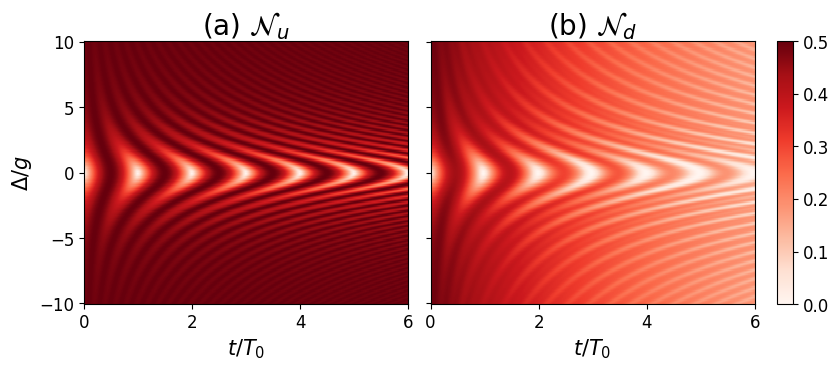

In [14]:
N_u_perp=np.loadtxt(f'robusteces/jcm/negatividad perp t0 u x=0.0g.txt')
# N_p0_perp=np.loadtxt(f'robusteces/jcm/negatividad perp t0 p=0 x=0.0g.txt')
N_p1_perp=np.loadtxt(f'robusteces/jcm/negatividad perp t0 p=0_01g x=0.0g.txt')
steps=3000*6
delta_array=np.linspace(-10*g,10*g,201)
t=np.linspace(0,6,steps)


fig_u = plt.figure(figsize=(8,3), dpi=100)

# Create a GridSpec with 1 row and 3 columns
# Make the third column (colorbar) much smaller
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.1)
# First subplot
ax_u = fig_u.add_subplot(gs[0, 0])
ax_u.set_title(r'(a) $\mathcal{N}_u$', pad=2, fontsize=20)
ax_u.set_xlabel('$t/T_0$')
ax_u.set_ylabel(r'$\Delta/g$')
c0 = ax_u.pcolor(t,delta_array/g,N_u_perp,
                 shading='auto', cmap='Reds', vmin=0, vmax=0.5)

# Second subplot
ax_d = fig_u.add_subplot(gs[0, 1])
ax_d.set_title(r'(b) $\mathcal{N}_d$', pad=2, fontsize=20)
ax_d.set_xlabel('$t/T_0$')
ax_d.set_yticklabels([])
c1 = ax_d.pcolor(t,delta_array/g,N_p1_perp,
                 shading='auto', cmap='Reds', vmin=0, vmax=0.5)

# Colorbar axis (small, independent)
ax_colorbar = fig_u.add_subplot(gs[0, 2])
fig_u.colorbar(c1, cax=ax_colorbar)

plt.show()

# heatplot(t,delta_array/g,N_u_perp,r'$\mathcal{N}_u$',r'$\Delta/g$')
# heatplot(t,delta_array/g,N_p0_perp,r'$\mathcal{N}_d$ ; $p=0$',r'$\Delta/g$')
# heatplot(t,delta_array/g,N_p1_perp,r'$\mathcal{N}_d$ ; $p=0.01g$',r'$\Delta/g$')

In [4]:
def ket_to_bloch(v1,v2,ket):
    sz_1=pr(v1)-pr(v2)
    sx_1=v1*v2.dag()+v2*v1.dag()
    sy_1=-1j*v1*v2.dag()+1j*v2*v1.dag()
    
    return [expect(sx_1,ket),expect(sy_1,ket),expect(sz_1,ket)]

C:\Users\alima\AppData\Local\Temp\ipykernel_24312\2191999600.py:22: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  h_vec=h_vec/np.sqrt(np.sum(h_vec_i**2 for h_vec_i in h_vec))


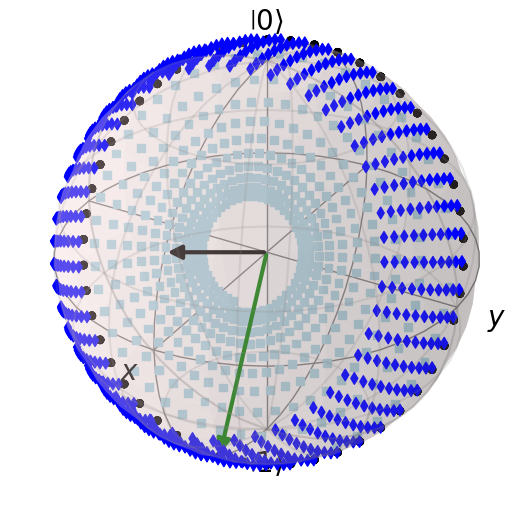

In [5]:
esfera=Bloch()
esfera.make_sphere()
delta=g
x=0
gamma=0.1*g
p=0.01*g
p0=0
p1=0.01*g
omega=np.sqrt(4*g**2+(delta-x)**2)

# # Simulacion numerica
num_ciclos=10
steps=3000*num_ciclos

T=2*np.pi/omega
t_final=num_ciclos*T
t=np.linspace(0,t_final,steps)
# delta_array=np.linspace(-10*g,10*g,201)
tita=np.arctan2(delta-x,-2*g)
# h_vec=[[g]*len(delta_array),[0]*len(delta_array),delta_array/2-[x/2]*len(delta_array)]
h_vec=[g,0,delta/2-x/2]
h_vec=h_vec/np.sqrt(np.sum(h_vec_i**2 for h_vec_i in h_vec)) 
esfera.add_vectors(h_vec,colors='black')

phi=0
psi_perp=np.cos(tita/2)*e0+np.sin(tita/2)*g1
esfera.add_vectors(ket_to_bloch(e0,g1,psi_perp),colors='green')
H=x*a.dag()*a*a.dag()*a+delta/2*sz + g*(a.dag()*sm+a*sp)

l_ops0=[np.sqrt(gamma)*a,np.sqrt(p0)*sm] #operadores de colapso/lindblad
l_ops1=[np.sqrt(gamma)*a,np.sqrt(p1)*sm] #operadores de colapso/lindblad

sol_u=mesolve(H,psi_perp,t)
sol_p0=mesolve(H,psi_perp,t,c_ops=l_ops0)
# sol_p1=mesolve(H,psi_perp,t,c_ops=l_ops1)
fg_p0,arg,eigenvals_t_d,psi_eig_p0 = fases(sol_p0)
# fg_p1,arg,eigenvals_t_d,psi_eig_p1 = fases(sol_p1)

ciclos_bloch=num_ciclos
points=ciclos_bloch*50

vBloch_tita=vectorBloch(e0,g1,sol_u.states,steps,ciclos_bloch,T,t_final,points)
esfera.add_points(vBloch_tita,'s',colors='black')

vBloch_tita=vectorBloch(e0,g1,sol_p0.states,steps,ciclos_bloch,T,t_final,points)
esfera.add_points(vBloch_tita,'s',colors='lightblue')

vBloch_tita=vectorBloch(e0,g1,psi_eig_p0,steps,ciclos_bloch,T,t_final,points)
esfera.add_points(vBloch_tita,'s',colors='blue')

esfera.render()
esfera.show()
plt.show()